In [32]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


# 1. تحديد الرابط والمتغيرات (الإحداثيات والتاريخ)
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 26.08,  # خط العرض لعنيزة 📍
    "longitude": 43.99,  # خط الطول لعنيزة 📍
    "start_date": "2023-01-01",  # بداية السنة 📅
    "end_date": "2023-12-31",  # نهاية السنة 📅
    "daily": [
        "temperature_2m_max",
        "temperature_2m_min",
        "temperature_2m_mean",
        "precipitation_sum",
    ],  # الحرارة والحرارة الصغرى/العظمى والأمطار 🌧️
    "timezone": "auto",
}

# 2. إرسال الطلب للـ API
response = requests.get(url, params=params)
data = response.json()

# 3. تحويل الجزء اليومي (daily) إلى DataFrame
df_raw = pd.DataFrame(data["daily"])
print(df_raw.head())

         time  temperature_2m_max  temperature_2m_min  temperature_2m_mean  \
0  2023-01-01                14.5                 9.6                 12.0   
1  2023-01-02                14.0                10.4                 11.9   
2  2023-01-03                17.3                11.4                 13.7   
3  2023-01-04                18.8                12.4                 14.9   
4  2023-01-05                14.7                 7.5                 11.2   

   precipitation_sum  
0               11.0  
1               13.9  
2                4.8  
3                8.2  
4                0.0  


In [33]:
# 1. تحويل الوقت وجعله مؤشراً (Index) 📅
df_raw['time'] = pd.to_datetime(df_raw['time'])
df_raw.set_index('time', inplace=True)

# 2. فحص القيم المفقودة 🔍
print("عدد القيم المفقودة:")
print(df_raw.isna().sum())

# 3. تطبيق الاستيفاء لمعالجة أي نقص دون إحداث فجوات 🧹
df_cleaned = df_raw.interpolate(method='linear')

# 4. حفظ النسخة المنظفة CSV 💾
df_cleaned.to_csv('weather_unaizah_cleaned.csv')

عدد القيم المفقودة:
temperature_2m_max     0
temperature_2m_min     0
temperature_2m_mean    0
precipitation_sum      0
dtype: int64


=== Descriptive Statistics ===
       temperature_2m_max  temperature_2m_min  temperature_2m_mean  \
count          365.000000          365.000000           365.000000   
mean            32.249315           19.671781            25.875890   
std              9.310427            7.647642             8.788346   
min             11.800000            4.400000             7.800000   
25%             24.800000           12.900000            18.600000   
50%             32.900000           19.900000            26.200000   
75%             41.100000           26.900000            34.500000   
max             45.000000           32.700000            38.400000   

       precipitation_sum  
count         365.000000  
mean            0.665753  
std             2.611630  
min             0.000000  
25%             0.000000  
50%             0.000000  
75%             0.000000  
max            27.500000  




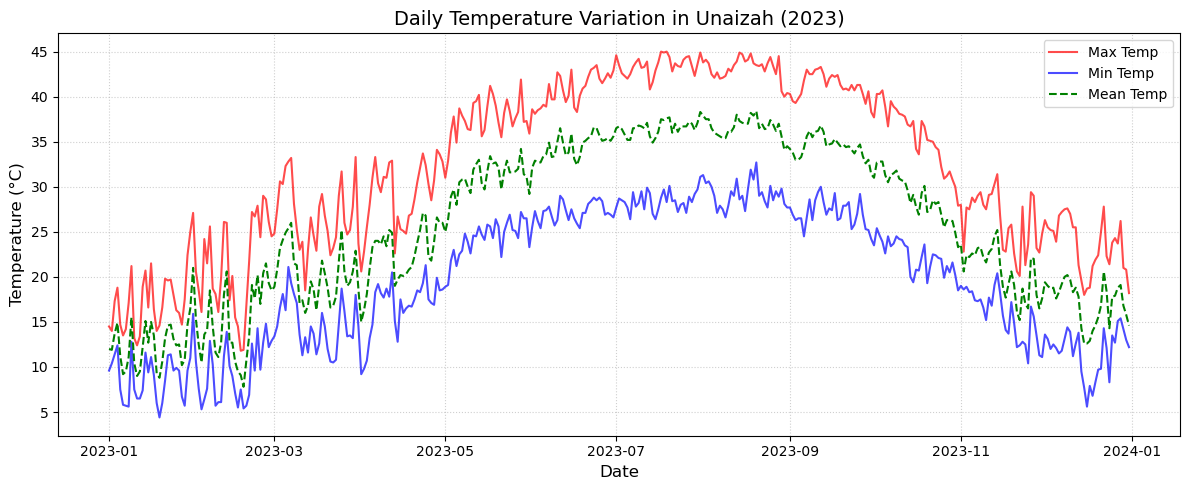

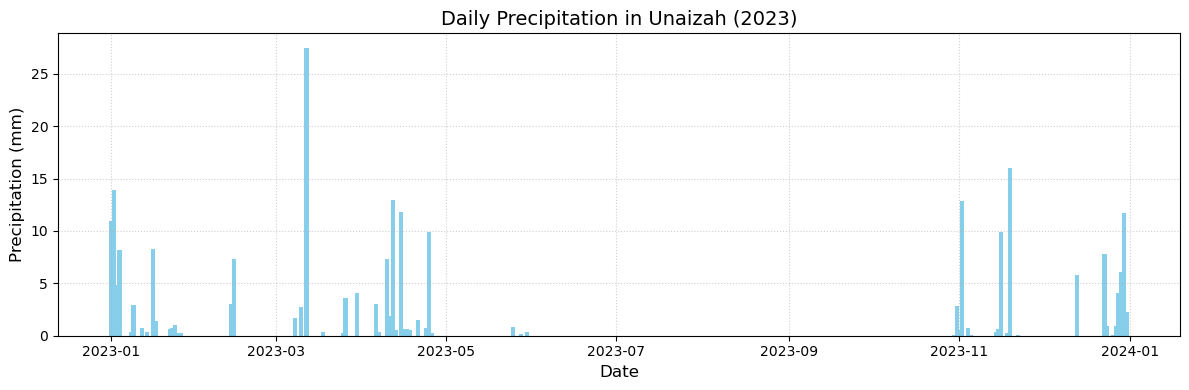

=== Monthly Summary ===
            temperature_2m_mean  temperature_2m_max  temperature_2m_min  \
time                                                                      
2023-01-31            12.541935                27.1                 4.4   
2023-02-28            14.753571                29.0                 5.3   
2023-03-31            20.229032                33.3                10.5   
2023-04-30            22.536667                34.1                 9.2   
2023-05-31            30.858065                41.9                18.9   
2023-06-30            34.453333                43.5                25.4   
2023-07-31            36.554839                45.0                26.4   
2023-08-31            36.629032                44.9                26.6   
2023-09-30            34.453333                43.3                24.2   
2023-10-31            28.961290                40.7                18.5   
2023-11-30            20.536667                31.4                10.4   
2

In [34]:
print("=== Descriptive Statistics ===")
print(df_cleaned.describe())
print("\n" + "=" * 40 + "\n")

# 2. Plot Temperature Time Series 🌡️
plt.figure(figsize=(12, 5))
plt.plot(
    df_cleaned.index,
    df_cleaned["temperature_2m_max"],
    label="Max Temp",
    color="red",
    alpha=0.7,
)
plt.plot(
    df_cleaned.index,
    df_cleaned["temperature_2m_min"],
    label="Min Temp",
    color="blue",
    alpha=0.7,
)
plt.plot(
    df_cleaned.index,
    df_cleaned["temperature_2m_mean"],
    label="Mean Temp",
    color="green",
    linestyle="--",
)

plt.title("Daily Temperature Variation in Unaizah (2023)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# 3. Plot Daily Precipitation 🌧️
plt.figure(figsize=(12, 4))
plt.bar(
    df_cleaned.index,
    df_cleaned["precipitation_sum"],
    color="skyblue",
    width=1.5,
)
plt.title("Daily Precipitation in Unaizah (2023)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Precipitation (mm)", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# 4. Monthly Aggregation 🗓️
monthly_summary = df_cleaned.resample("M").agg(
    {
        "temperature_2m_mean": "mean",
        "temperature_2m_max": "max",
        "temperature_2m_min": "min",
        "precipitation_sum": "sum",
    }

)

print("=== Monthly Summary ===")
print(monthly_summary)

In [35]:
# تحديد Target و Features
# 1. إضافة رقم الشهر (1-12) 📅
df_cleaned["month"] = df_cleaned.index.month

# 2. إضافة رقم اليوم من السنة (1-365) 📆
df_cleaned["day_of_year"] = df_cleaned.index.dayofyear

X = df_cleaned[
    [
        "temperature_2m_min",
        "temperature_2m_mean",
        "precipitation_sum",
        "month",
        "day_of_year",
    ]
]
y = df_cleaned["temperature_2m_max"]

# التقسيم الزمني (80% تدريب - 20% اختبار)
train_size = int(len(df_cleaned) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]


# 1. إنشاء كائن النموذج
model = LinearRegression()
# 1. تدريب النموذج 🏋️‍♂️
model.fit(X_train, y_train)

# 2. التنبؤ على بيانات الاختبار 🔮
y_pred = model.predict(X_test)

# 3. حساب مقاييس التقييم (MAE و RMSE) 📏
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.2f} °C")
print(f"RMSE: {rmse:.2f} °C")

MAE: 0.68 °C
RMSE: 0.91 °C


In [36]:


# 1. إنشاء نموذج الغابات العشوائية 🌲
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. تدريب النموذج 🏋️‍♂️
rf_model.fit(X_train, y_train)

# 3. التنبؤ على بيانات الاختبار 🔮
y_pred_rf = rf_model.predict(X_test)

# 4. حساب مقاييس التقييم 📏
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Random Forest MAE: {mae_rf:.2f} °C")
print(f"Random Forest RMSE: {rmse_rf:.2f} °C")

Random Forest MAE: 1.31 °C
Random Forest RMSE: 1.56 °C


In [37]:


# 1. إنشاء خاصية اليوم السابق وتنظيف البيانات ⏪
df_cleaned["temp_max_yesterday"] = df_cleaned["temperature_2m_max"].shift(1)
df_cleaned = df_cleaned.dropna()

# 2. تحديث قائمة الخصائص X وشفرة الهدف y 🎯
X = df_cleaned[
    [
        "temperature_2m_min",
        "temperature_2m_mean",
        "precipitation_sum",
        "temp_max_yesterday",
    ]
]
y = df_cleaned["temperature_2m_max"]

# 3. التقسيم الزمني للبيانات ✂️
train_size = int(len(df_cleaned) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# 4. تدريب نموذج الانحدار الخطي 📉
model = LinearRegression()
model.fit(X_train, y_train)

# 5. التنبؤ وحساب الأخطاء 📏
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE مع الخاصية المتأخرة: {mae:.2f} °C")
print(f"RMSE مع الخاصية المتأخرة: {rmse:.2f} °C")

MAE مع الخاصية المتأخرة: 0.67 °C
RMSE مع الخاصية المتأخرة: 0.88 °C


In [38]:
print(df_cleaned.columns)

Index(['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
       'precipitation_sum', 'month', 'day_of_year', 'temp_max_yesterday'],
      dtype='object')


In [39]:


# 1. إضافة خاصية الحرارة قبل يومين وتنظيف الصفوف الفارغة ⏪
df_cleaned["temp_max_2days_ago"] = df_cleaned["temperature_2m_max"].shift(2)
df_cleaned = df_cleaned.dropna()

# 2. تحديث الخصائص X لتقرأ الحرارة العظمى للأمس وقبل الأمس 🎯
X = df_cleaned[
    [
        "temperature_2m_min",
        "temperature_2m_mean",
        "precipitation_sum",
        "temp_max_yesterday",
        "temp_max_2days_ago",
    ]
]
y = df_cleaned["temperature_2m_max"]

# 3. التقسيم الزمني للبيانات ✂️
train_size = int(len(df_cleaned) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# 4. تدريب النموذج وحساب الأخطاء 📏
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE الجديد: {mae:.2f} °C")
print(f"RMSE الجديد: {rmse:.2f} °C")

MAE الجديد: 0.69 °C
RMSE الجديد: 0.91 °C


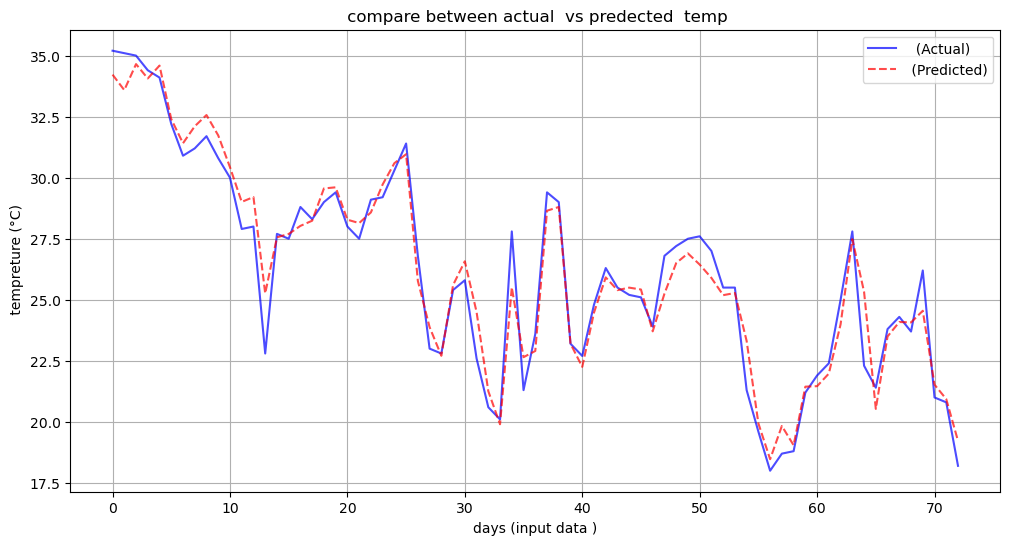

In [40]:

# تحديد حجم الشكل
plt.figure(figsize=(12, 6))

# رسم القيم الفعلية والتوقعات
plt.plot(
    y_test.values, label="  (Actual)", color="blue", alpha=0.7
)
plt.plot(
    y_pred,
    label=" (Predicted)",
    color="red",
    linestyle="--",
    alpha=0.7,
)

# إضافة العناوين والرموز
plt.title(" compare between actual  vs predected  temp")
plt.xlabel("days (input data )")
plt.ylabel(" tempreture (°C)")
plt.legend()
plt.grid(True)

plt.show()

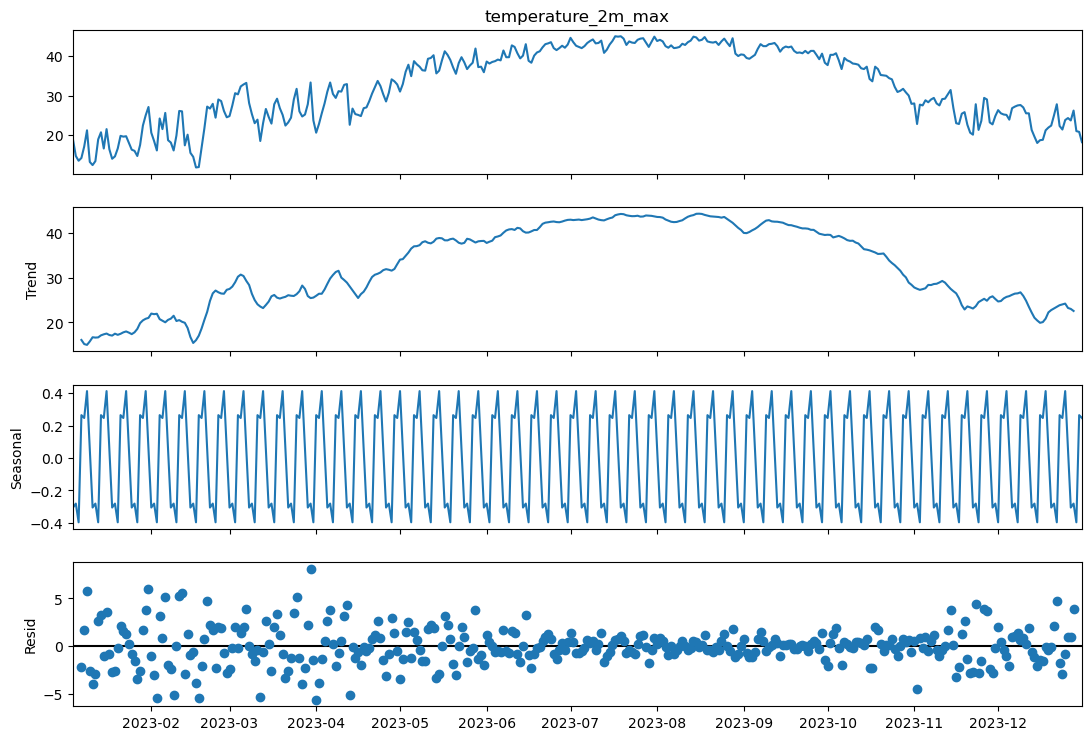

--- ADF Test Results ---
ADF Statistic: -1.4195
p-value: 0.5729
النتيجة: السلسلة الزمنية غير مستقرة (Non-Stationary)


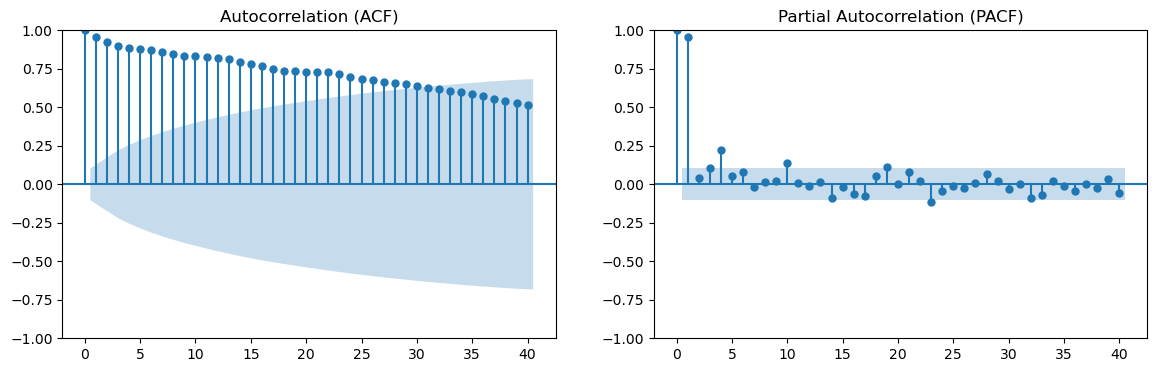

In [42]:
decomposition = seasonal_decompose(
    df_cleaned["temperature_2m_max"], model="additive", period=7
)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

# 2. اختبار الاستقرارية (Augmented Dickey-Fuller Test) 📏
adf_result = adfuller(df_cleaned["temperature_2m_max"].dropna())
print("--- ADF Test Results ---")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
if adf_result[1] < 0.05:
  print(
      "النتيجة: السلسلة الزمنية مستقرة (Stationary) لأن قيمة p-value أقل من 0.05"
  )
else:
  print("النتيجة: السلسلة الزمنية غير مستقرة (Non-Stationary)")

# 3. مخططات الارتباط الذاتي ACF و PACF 📊
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df_cleaned["temperature_2m_max"].dropna(), ax=axes[0], lags=40)
axes[0].set_title("Autocorrelation (ACF)")

plot_pacf(
    df_cleaned["temperature_2m_max"].dropna(), ax=axes[1], lags=40, method="ywm"
)
axes[1].set_title("Partial Autocorrelation (PACF)")
plt.show()

In [43]:
# 1. حساب الارتباط بين درجات الحرارة والأمطار 🌧️🌡️
correlation = df_cleaned[['temperature_2m_max', 'precipitation_sum']].corr()
print("--- Correlation Matrix ---")
print(correlation)

# 2. كشف الشذوذ باستخدام نافذة متحركة (Rolling Window) 📉
rolling_mean = df_cleaned['temperature_2m_max'].rolling(window=7).mean()
rolling_std = df_cleaned['temperature_2m_max'].rolling(window=7).std()

# القيم التي تبتعد أكثر من 3 انحرافات معيارية عن المتوسط المتحرك
anomalies = df_cleaned[abs(df_cleaned['temperature_2m_max'] - rolling_mean) > (3 * rolling_std)]
print(f"عدد القيم الشاذة المكتشفة: {len(anomalies)}")

--- Correlation Matrix ---
                    temperature_2m_max  precipitation_sum
temperature_2m_max            1.000000          -0.217936
precipitation_sum            -0.217936           1.000000
عدد القيم الشاذة المكتشفة: 0


In [44]:
# حفظ جدول البيانات النظيفة كملف CSV جاهز للتسليم
df_cleaned.to_csv("cleaned_weather_data.csv", index=False)
print("تم حفظ ملف البيانات النظيفة (cleaned_weather_data.csv) بنجاح!")

تم حفظ ملف البيانات النظيفة (cleaned_weather_data.csv) بنجاح!
